## Notebook to explore hpo similarity matching using oaklib and semsimian to enable gene level phenotype matching for the AIP

Reviewing the notebook after I am done, I can see all of the oaklib playing has been purged over time. My basic summary is that this all worked via oaklib but by default it would run using the native python implementation which is super slow. The idea is you can just swap to use the wrapped semsimian implementation, but like everything in oaklib figuring out how to set that config was not clear. Basically, the whole package drove me up the wall trying to make it do anything.

After some play, it was clear all I needed for my purposes was to call semsimian directly, so I did that and there was peace in my heart.


In [162]:
# ! pip install oaklib semsimian
# ! brew install xz

import numpy as np
import pandas as pd
%matplotlib inline

In [ ]:
## Download latest phenio.db from HPO site. This is meant to "be taken care of" by oaklib
# but the lack of lzma in my local python install is causing issues.
!wget https://data.monarchinitiative.org/monarch-kg/latest/phenio.db.gz
! gunzip phenio.db.gz

In [163]:
from semsimian import Semsimian

db = "phenio.db"

#  Predicates basicly define what types of edges in the graph should be considered a "link".
# For HPO we are only interested in the "rdfs:subClassOf" predicate.
predicates = ["rdfs:subClassOf"]

semsimian = Semsimian(
    spo=None,
    predicates=predicates,
    resource_path=db,
)

In [164]:
# some example HPO sets
hpo1 = {"HP:0012469", "HP:0020219"}
hpo2 = {"HP:0007270", "HP:0100763"}
hpo3 = {"HP:0011097", "HP:0032843"}


In [165]:
%%time

# Run a termset comparison. First run sets up some internal data structures, so it's slower.
full_result = semsimian.termset_pairwise_similarity(
    set(hpo1),
    set(hpo2),
)
full_result
# full_result['best_score']

CPU times: user 4.8 s, sys: 265 ms, total: 5.06 s
Wall time: 5.07 s


{'subject_termset': [{'HP:0020219': {'id': 'HP:0020219',
    'label': 'Motor seizure (HPO)'}},
  {'HP:0012469': {'id': 'HP:0012469', 'label': 'Infantile spasms (HPO)'}}],
 'object_termset': [{'HP:0100763': {'id': 'HP:0100763',
    'label': 'Abnormality of the lymphatic system (HPO)'}},
  {'HP:0007270': {'id': 'HP:0007270',
    'label': 'Atypical absence seizure (HPO)'}}],
 'subject_best_matches': {'similarity': {'HP:0012469': {'ancestor_id': 'HP:0001250',
    'ancestor_information_content': '9.678994670483071',
    'ancestor_label': 'Seizure (HPO)',
    'cosine_similarity': 'NaN',
    'jaccard_similarity': '0.7037037037037037',
    'object_id': 'HP:0007270',
    'phenodigm_score': '2.609816928013792',
    'subject_id': 'HP:0012469'},
   'HP:0020219': {'ancestor_id': 'HP:0001250',
    'ancestor_information_content': '9.678994670483071',
    'ancestor_label': 'Seizure (HPO)',
    'cosine_similarity': 'NaN',
    'jaccard_similarity': '0.76',
    'object_id': 'HP:0007270',
    'phenodigm_s

In [166]:
%%time

full_result = semsimian.termset_pairwise_similarity(
    set(hpo1),
    set(hpo3),
)
full_result['best_score']

CPU times: user 1.79 ms, sys: 1.09 ms, total: 2.88 ms
Wall time: 10.1 ms


15.536975665610642

In [167]:
## Lets run this on a real AIP output

#Import a genes to phenotype mapping. I think this can be extracted from the phenio.db file,
# but I'm not sure how so we are using the mapping file from the HPO website.
from collections import defaultdict
with open("/Users/cas/Downloads/genes_to_phenotype.txt") as f:
    gene_to_phenotype = defaultdict(set)
    for line in f:
        ncbi_gene_id, gene_symbol, hpo_id, hpo_name, frequency, disease_id = line.split("\t")
        gene_to_phenotype[gene_symbol].add(hpo_id)

In [ ]:
# read in aip json results file
import json
with open("/Users/cas/Downloads/acute_care.genome.summary_output.json") as f:
    aip_results_summary = json.load(f)
aip_results_summary

In [ ]:

matched_best_scores = []
unmatched_best_scores = []
unmatched_best_jaccard_similarity = []
matched_best_jaccard_similarity = []

matched_similarity_results = []
unmatched_similarity_results = []


for sgid_id, aip_sample_results in aip_results['results'].items():
    # print(sgid_id)
    # print(aip_sample_results)
    case_phenotypes = {hpo.split()[0] for hpo in aip_sample_results['metadata']['phenotypes'] if hpo.startswith("HP:")}

    print('SG:', sgid_id)
    print('case_phenotypes:', case_phenotypes)
    for varaint in aip_sample_results['variants']:
        if 'transcript_consequences' not in varaint['var_data']:
            continue
        varaint_genes = set(cons['symbol'] for cons in varaint['var_data']['transcript_consequences'])
        # print(varaint_genes)

        ## Get HPO terms assocaited with each gene
        varaint_phenotypes = set()
        for symbol in varaint_genes:
            varaint_phenotypes.update(gene_to_phenotype[symbol])
        # print('varaint_phenotypes:', varaint_phenotypes)

        if not case_phenotypes or not varaint_phenotypes:
            continue

        # Compare termsets and get best score
        termset_similarity = semsimian.termset_pairwise_similarity(
            case_phenotypes,
            varaint_phenotypes,
        )

        max_jaccard = max([float(match['jaccard_similarity']) for match in termset_similarity['subject_best_matches']['similarity'].values()])
        if varaint['panels']['matched']:
            matched_best_scores.append(termset_similarity['best_score'])
            matched_similarity_results.append(termset_similarity)
            matched_best_jaccard_similarity.append(max_jaccard)

        else:
            unmatched_best_scores.append(termset_similarity['best_score'])
            unmatched_similarity_results.append(termset_similarity)
            unmatched_best_jaccard_similarity.append(max_jaccard)


        # print('best score:', termset_similarity['best_score'])
        # print(varaint['panels']['matched'])


In [173]:
matched_pd = pd.DataFrame({'Matched IC': matched_best_scores})
unmatched_pd = pd.DataFrame({'Unmatched IC': unmatched_best_scores})
unmatched_jaccard_pd = pd.DataFrame({'Unmatched Jaccard': unmatched_best_jaccard_similarity})
matched_jaccard_pd = pd.DataFrame({'matched Jaccard': matched_best_jaccard_similarity})


array([[<Axes: title={'center': 'Matched IC'}>]], dtype=object)

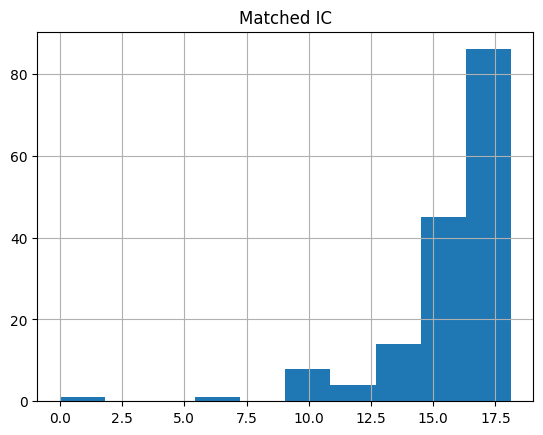

In [174]:
matched_pd.hist()

array([[<Axes: title={'center': 'Unmatched IC'}>]], dtype=object)

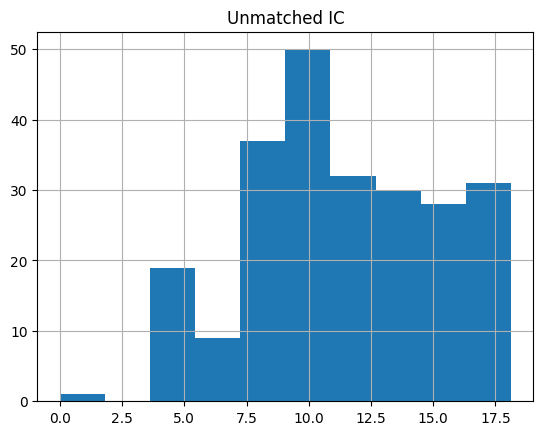

In [175]:
unmatched_pd.hist()

array([[<Axes: title={'center': 'matched Jaccard'}>]], dtype=object)

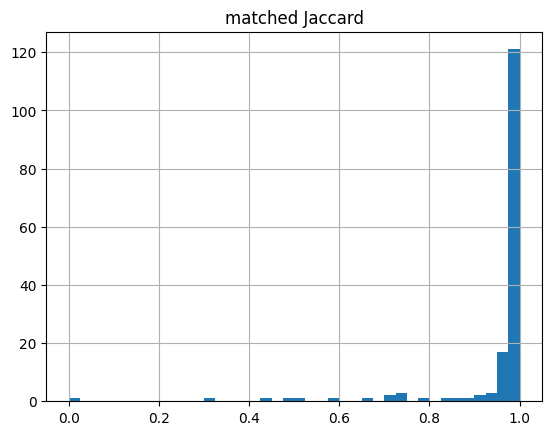

In [176]:
matched_jaccard_pd.hist(bins=40)

array([[<Axes: title={'center': 'Unmatched Jaccard'}>]], dtype=object)

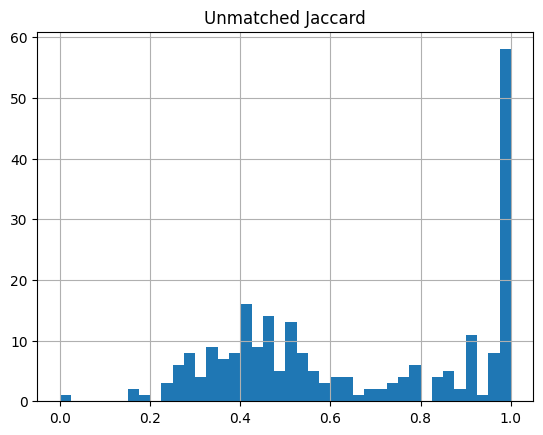

In [177]:
unmatched_jaccard_pd.hist(bins=40)

In [178]:
# Lets see if there are some over represented terms in the high scoring unmatched variants
high_scoring_ancestors = []
for termset_similarity in unmatched_similarity_results:
    if termset_similarity['best_score'] > 12.5:
        for value in termset_similarity['subject_best_matches']['similarity'].values():
            if float(value['ancestor_information_content']) > 12.5:
                high_scoring_ancestors.append(value['ancestor_label'])

from collections import Counter
high_scoring_ancestors_counts = Counter(high_scoring_ancestors)
high_scoring_ancestors_counts.most_common()

# These all look reasnobly specific... That's good.


[('Microcephaly (HPO)', 7),
 ('Growth delay (HPO)', 6),
 ('Hypotonia (HPO)', 6),
 ('Polyhydramnios (HPO)', 5),
 ('Encephalopathy (HPO)', 4),
 ('Edema (HPO)', 4),
 ('Decreased body weight (HPO)', 4),
 ('Neurodevelopmental abnormality (HPO)', 3),
 ('Epileptic encephalopathy (HPO)', 3),
 ('Cardiomyopathy (HPO)', 3),
 ('Dilated cardiomyopathy (HPO)', 3),
 ('Short stature (HPO)', 3),
 ('Abnormality of the forehead (HPO)', 3),
 ('Respiratory insufficiency (HPO)', 3),
 ('Ventricular septal defect (HPO)', 3),
 ('Global developmental delay (HPO)', 2),
 ('Failure to thrive (HPO)', 2),
 ('Apnea (HPO)', 2),
 ('Feeding difficulties (HPO)', 2),
 ('Low-set ears (HPO)', 2),
 ('Anemia (HPO)', 2),
 ('Abnormal cardiac septum morphology (HPO)', 2),
 ('Micrognathia (HPO)', 2),
 ('Polyuria (HPO)', 2),
 ('Abnormal blood monovalent inorganic cation concentration (HPO)', 2),
 ('Hypochloremia (HPO)', 2),
 ('Metabolic alkalosis (HPO)', 2),
 ('Pleural effusion (HPO)', 2),
 ('Abnormal circulating methionine concen

### Below are ROC plots based on the ouput from the hpo_comparison/add_gene_level_matching_to_AIP.py script

In [180]:
import pandas as pd
from sklearn.metrics import roc_curve

file_path = '~/Downloads/acute_care.genome.summary_output.pos_variant_scores.json'

# with open(file_path, 'r') as file:
#     data = json.load(file)
df = pd.read_json(file_path)


# Now you can work with the parsed JSON data
# For example, you can access specific fields or iterate over the data
ic_fpr, ic_tpr, ic_thresholds = roc_curve(df['true_positive'], df['max_IC_score'])
jac_fpr, jac_tpr, jac_thresholds = roc_curve(df['true_positive'], df['max_jaccard_score'])


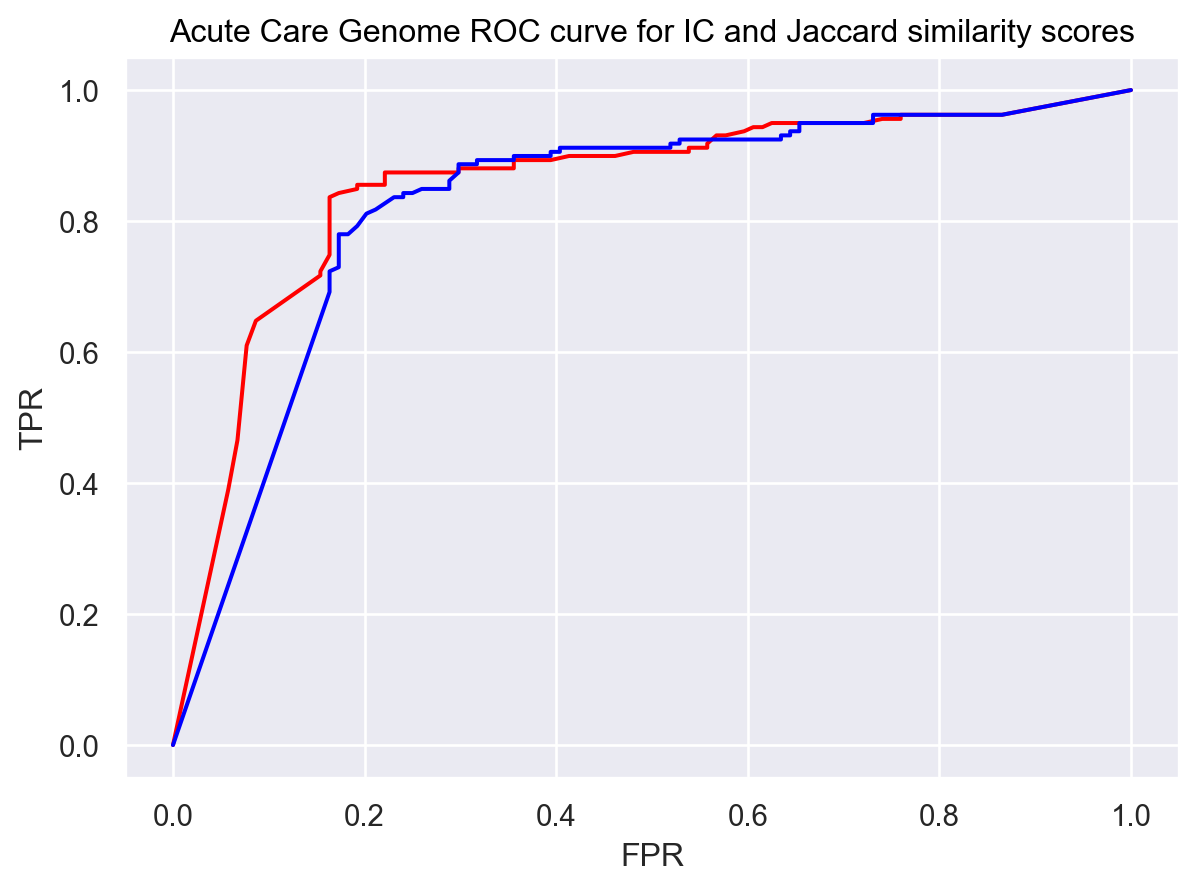

In [181]:
import seaborn.objects as so
so.Plot().add(so.Line(color = 'red'),x =ic_fpr, y = ic_tpr).add(so.Line(color = 'blue'),x =jac_fpr, y = jac_tpr).label(x="FPR", y="TPR", title="Acute Care Genome ROC curve for IC and Jaccard similarity scores")
# p.show()

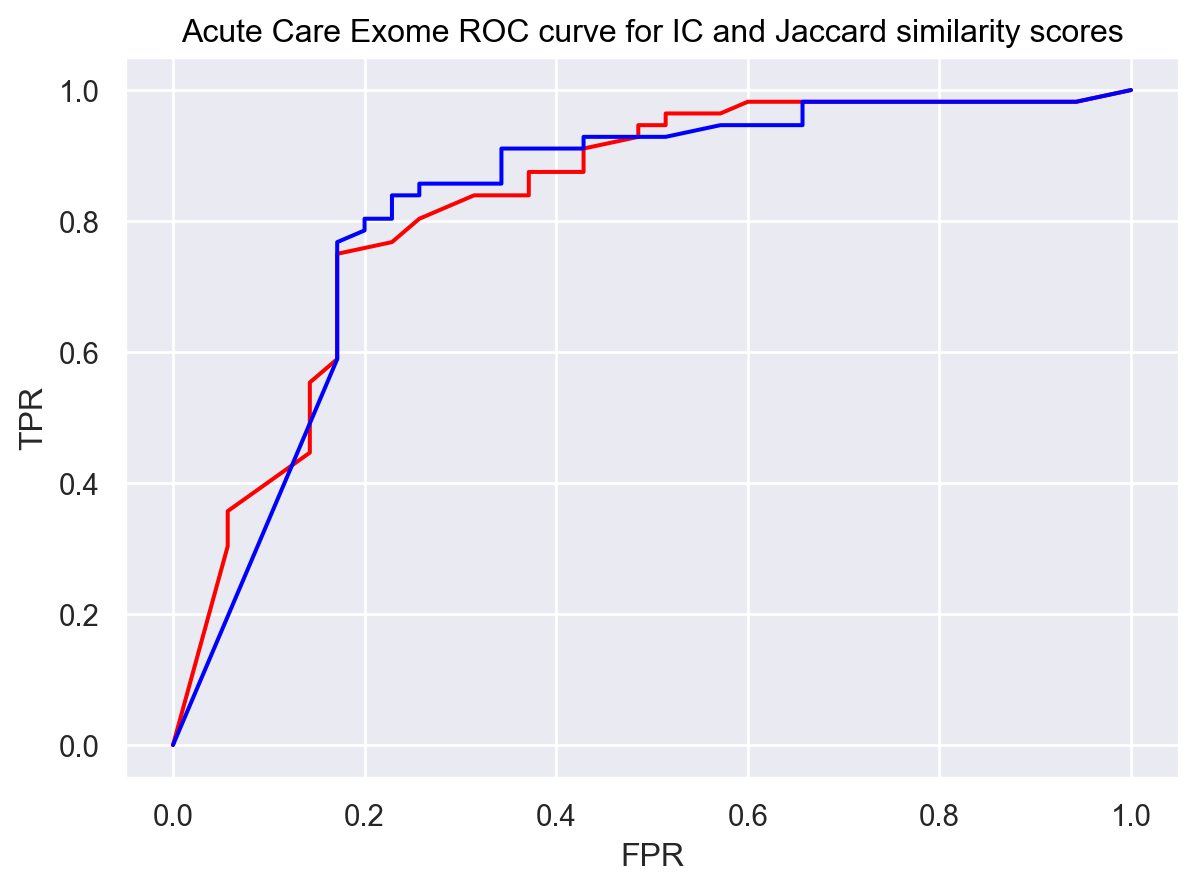

In [182]:
file_path = '~/Downloads/acute-care.exome.2024-03-08.summary_output.pos_variant_scores.json'

# with open(file_path, 'r') as file:
#     data = json.load(file)
df = pd.read_json(file_path)

ic_fpr, ic_tpr, ic_thresholds = roc_curve(df['true_positive'], df['max_IC_score'])
jac_fpr, jac_tpr, jac_thresholds = roc_curve(df['true_positive'], df['max_jaccard_score'])

so.Plot().add(so.Line(color = 'red'),x =ic_fpr, y = ic_tpr).add(so.Line(color = 'blue'),x =jac_fpr, y = jac_tpr).label(x="FPR", y="TPR", title="Acute Care Exome ROC curve for IC and Jaccard similarity scores")
